# Week 1 · Descriptive Statistics & Data Types

*DS 207 · Week 1*

Every dataset makes silent promises about the kind of arithmetic you're allowed to do on it. This week builds the vocabulary and tools to profile a raw dataset responsibly: identifying what each column actually measures, choosing the right "typical value," quantifying how spread out the data is, and catching the traps that make a single summary statistic misleading.

**Author:** EC Corro, built in collaboration with Claude, ChatGPT, and Gemini

## Learning Objectives

- Classify any variable into its correct level of measurement (nominal, ordinal, interval, ratio) and explain why that classification restricts which statistics and operations are valid.
- Compute mean, median, and mode by hand and in code, and identify the specific conditions under which each one misrepresents the data.
- Compute range, variance, standard deviation, and interquartile range by hand and in code, and explain what each spread measure captures that the others miss.
- Perform a structured data-profiling pass on a raw dataset (data types, missing values, duplicates, impossible values, outliers) before trusting any downstream number.
- Connect each statistical result to a concrete business decision made by a named stakeholder.

**Prerequisites:** basic algebra (summation notation), comfort reading a Python function, and a working Jupyter environment with `numpy`, `pandas`, `scipy`, `matplotlib`, and `seaborn` installed.

## Business Context

IslaCart is a mid-sized online retailer based in Cebu City, shipping electronics, apparel, home goods, beauty products, and groceries across the Visayas region. The company's operations and finance teams are preparing to feed last quarter's raw order export into pricing and inventory-planning models. Before any of those numbers reach a dashboard or a forecast, **Ana Villareal, IslaCart's Data & Analytics Lead**, has one job this week: make sure nobody on the leadership team draws a business conclusion from a statistic that's lying to them. This notebook walks through the four checks she runs on every fresh export — starting with the most basic question of all: *what kind of data am I even looking at?*

## Setup: The IslaCart Q2 Orders Export

The cell below generates the dataset used throughout this notebook: a synthetic but realistic export of IslaCart's Q2 orders, deliberately built with a mix of nominal, ordinal, interval, and ratio columns, and — for Subtopic 4 — a handful of the data-quality issues Ana actually finds in real exports. Run this once; every subtopic below reuses `orders_df`.

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(207)
sns.set_style("whitegrid")

N = 500

# --- Nominal columns ---
segments = rng.choice(
    ["New", "Returning", "VIP"], size=N, p=[0.45, 0.47, 0.08]
)
categories = rng.choice(
    ["Electronics", "Apparel", "Home & Living", "Beauty", "Grocery"],
    size=N, p=[0.22, 0.28, 0.18, 0.17, 0.15]
)
regions = rng.choice(
    ["Cebu City", "Mandaue", "Lapu-Lapu", "Talisay", "Outside Cebu"],
    size=N, p=[0.35, 0.20, 0.15, 0.12, 0.18]
)

# --- Ordinal columns ---
shipping_tier = rng.choice(
    ["Standard", "Expedited", "Overnight"], size=N, p=[0.60, 0.30, 0.10]
)
shipping_rank = pd.Categorical(
    shipping_tier, categories=["Standard", "Expedited", "Overnight"], ordered=True
)
satisfaction = rng.choice([1, 2, 3, 4, 5], size=N, p=[0.03, 0.07, 0.15, 0.40, 0.35])

# --- Interval column ---
order_date = pd.to_datetime("2026-04-01") + pd.to_timedelta(
    rng.integers(0, 91, size=N), unit="D"
)

# --- Ratio columns ---
tier_delay = {"Standard": 4.0, "Expedited": 2.0, "Overnight": 0.7}
base_delay = np.array([tier_delay[t] for t in shipping_tier])
delivery_days = np.clip(rng.normal(base_delay, 1.0), 0.2, None).round(1)

segment_mult = {"New": 1.0, "Returning": 1.15, "VIP": 4.5}
base_value = rng.gamma(shape=3.0, scale=180, size=N)
order_value_php = (base_value * np.array([segment_mult[s] for s in segments])).round(2)

orders_df = pd.DataFrame({
    "order_id": [f"IC-{i:05d}" for i in range(1, N + 1)],
    "customer_segment": segments,
    "product_category": categories,
    "region": regions,
    "shipping_tier": shipping_rank,
    "customer_satisfaction": satisfaction,
    "order_date": order_date,
    "delivery_days": delivery_days,
    "order_value_php": order_value_php,
})

orders_df.head()

,order_id,customer_segment,product_category,region,shipping_tier,customer_satisfaction,order_date,delivery_days,order_value_php
0,IC-00001,New,Grocery,Outside Cebu,Overnight,5,2026-05-13,0.2,151.06
1,IC-00002,Returning,Home & Living,Outside Cebu,Standard,4,2026-06-29,6.3,533.73
2,IC-00003,Returning,Beauty,Cebu City,Standard,4,2026-06-17,3.2,852.78
3,IC-00004,Returning,Apparel,Talisay,Standard,2,2026-06-30,1.5,472.06
4,IC-00005,Returning,Apparel,Mandaue,Standard,4,2026-05-28,2.0,369.58


> **A note on `order_date`:** dates are treated as an *interval* variable here — the gap between two dates is meaningful and additive (an order placed on April 10 is exactly 9 days after one placed on April 1), but "day zero" is a calendar convention, not a true absence of time. Once we convert a date into "days since campaign launch" or "days to deliver," that derived quantity becomes a ratio variable, because zero now genuinely means *no elapsed time*.

## Subtopic 1: Data Types and Levels of Measurement

### Intuition & Analogy

**Business Hook:** Ana's engineering team wants to know — *which columns in this export can we legally average, rank, or run a t-test on, and which ones would produce a nonsense number if we tried?*

Think of four ways people get labeled at a run:

- **Bib numbers** (nominal) — #14, #52, #101. They identify runners. Averaging them (mean bib number = 55.6) tells you nothing.
- **Finish rank** (ordinal) — 1st, 2nd, 3rd place. You know the order, but not the gap: 1st might have finished 30 seconds before 2nd, while 2nd finished 20 minutes before 3rd.
- **Temperature at the start line, °C** (interval) — 20°C is genuinely 10 degrees warmer than 10°C, and the gaps are comparable. But 0°C is not "no temperature," so you can't say 20°C is "twice as hot" as 10°C.
- **Finish time, minutes** (ratio) — a true zero exists (no time elapsed), so ratios are meaningful: a 40-minute finisher really did run twice as fast as an 80-minute finisher.

IslaCart's `order_id` is a bib number. `shipping_tier` is a finish rank. `order_date` behaves like the start-line temperature. `order_value_php` and `delivery_days` behave like finish time.

| Level | Can you... rank? | ...compute meaningful differences? | ...compute meaningful ratios? | IslaCart example |
|---|---|---|---|---|
| Nominal | No | No | No | `region`, `product_category` |
| Ordinal | Yes | Not reliably | No | `shipping_tier`, `customer_satisfaction` |
| Interval | Yes | Yes | No | `order_date` |
| Ratio | Yes | Yes | Yes | `order_value_php`, `delivery_days` |

### Theory — By Hand

Take four rows pulled directly from the export:

| `order_id` | `region` | `shipping_tier` | `customer_satisfaction` | `order_value_php` |
|---|---|---|---|---|
| IC-00012 | Mandaue | Standard | 4 | 540.00 |
| IC-00047 | Cebu City | Overnight | 5 | 2,150.00 |
| IC-00081 | Lapu-Lapu | Expedited | 3 | 890.50 |
| IC-00103 | Cebu City | Standard | 2 | 310.75 |

Classify each column by asking three questions in order:

1. **Does order carry meaning?** If no → nominal. `region` fails here: "Mandaue" is not "more" or "less" than "Cebu City." → **Nominal.**
2. **If order matters, are the gaps between values equal and meaningful?** `shipping_tier` (Standard < Expedited < Overnight) and `customer_satisfaction` (2 < 3 < 4 < 5) both have meaningful order, but the *distance* between "Standard" and "Expedited" is not demonstrably equal to the distance between "Expedited" and "Overnight" — and the emotional gap between a 2-star and 3-star review is not guaranteed to equal the gap between a 4-star and 5-star review. → **Ordinal** for both.
3. **If gaps are equal, is there a true zero where "zero" means "none of this quantity"?** `order_value_php` has both equal, meaningful gaps (₱100 is always ₱100, anywhere on the scale) *and* a true zero (₱0.00 means the order was worth nothing). → **Ratio.**

So: `order_id` → nominal (identifier only), `region` → nominal, `shipping_tier` → ordinal, `customer_satisfaction` → ordinal, `order_value_php` → ratio.

A quick consequence Ana cares about: because `customer_satisfaction` is ordinal, "average satisfaction is 3.8 stars" is a number analysts compute constantly, but strictly speaking it assumes the gap between 3 and 4 stars equals the gap between 4 and 5 — an assumption worth stating out loud, not hiding.

In [ ]:
# Verifying the by-hand classification against the four sample rows

sample = orders_df.loc[
    orders_df["order_id"].isin(["IC-00012", "IC-00047", "IC-00081", "IC-00103"]),
    ["order_id", "region", "shipping_tier", "customer_satisfaction", "order_value_php"]
]
print(sample.to_string(index=False))

# pandas dtypes hint at, but do not guarantee, level of measurement --
# "shipping_tier" is stored as an ORDERED Categorical, which is how pandas
# represents ordinal data. "region" is a plain object/string column: nominal.
print("\ndtypes:")
print(orders_df[["region", "shipping_tier", "customer_satisfaction", "order_value_php"]].dtypes)

print("\nIs shipping_tier ordered?", orders_df["shipping_tier"].cat.ordered)

order_id    region shipping_tier  customer_satisfaction  order_value_php
IC-00012 Cebu City      Standard                      4           754.11
IC-00047   Talisay      Standard                      5          1035.32
IC-00081 Cebu City     Expedited                      4           314.46
IC-00103   Mandaue      Standard                      5          2324.12

dtypes:
region                        str
shipping_tier            category
customer_satisfaction       int64
order_value_php           float64
dtype: object

Is shipping_tier ordered? True


In [ ]:
# What happens if we ignore the level of measurement and average a nominal
# column anyway? pandas will refuse for strings -- but a common real mistake
# is to numerically ENCODE a nominal column (e.g. region -> 0,1,2,3,4) and
# then average the codes, which silently produces a meaningless number.

region_codes = orders_df["region"].astype("category").cat.codes
print("Nonsense 'average region':", region_codes.mean().round(2))
print("This number does not correspond to any real region -- it is an", end=" ")
print("artifact of alphabetical coding order, not a business insight.")

Nonsense 'average region': 1.52
This number does not correspond to any real region -- it is an artifact of alphabetical coding order, not a business insight.


### By Tool

Across the full 500-row export, we classify every column programmatically and confirm the classification is consistent with how pandas is storing the data.

In [ ]:
level_of_measurement = {
    "order_id": "Nominal (identifier)",
    "customer_segment": "Nominal",
    "product_category": "Nominal",
    "region": "Nominal",
    "shipping_tier": "Ordinal",
    "customer_satisfaction": "Ordinal",
    "order_date": "Interval",
    "delivery_days": "Ratio",
    "order_value_php": "Ratio",
}

schema = pd.DataFrame({
    "dtype": orders_df.dtypes.astype(str),
    "level_of_measurement": pd.Series(level_of_measurement),
    "n_unique": orders_df.nunique(),
})
schema

,dtype,level_of_measurement,n_unique
order_id,str,Nominal (identifier),500
customer_segment,str,Nominal,3
product_category,str,Nominal,5
region,str,Nominal,5
shipping_tier,category,Ordinal,3
customer_satisfaction,int64,Ordinal,5
order_date,datetime64[us],Interval,90
delivery_days,float64,Ratio,62
order_value_php,float64,Ratio,500


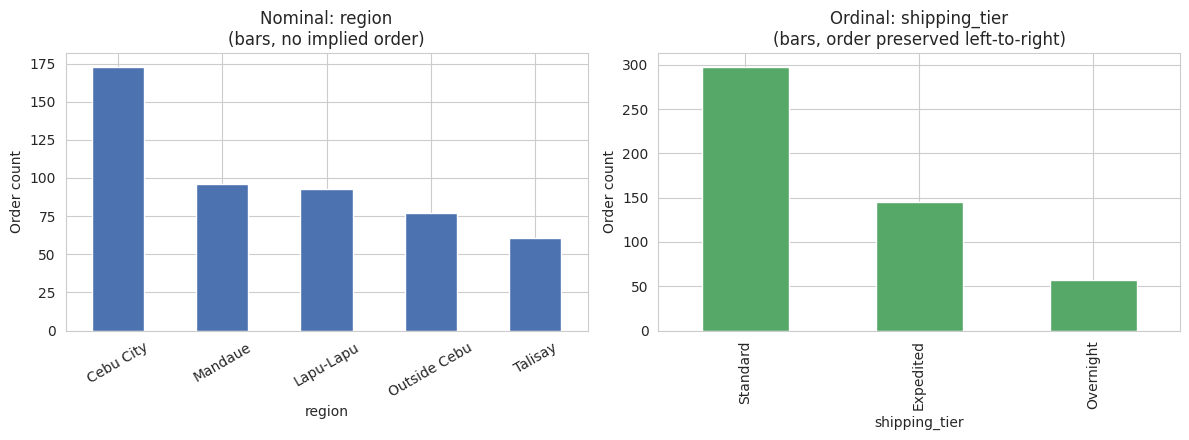

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

orders_df["region"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Nominal: region\n(bars, no implied order)")
axes[0].set_ylabel("Order count")
axes[0].tick_params(axis="x", rotation=30)

tier_order = ["Standard", "Expedited", "Overnight"]
orders_df["shipping_tier"].value_counts().reindex(tier_order).plot(
    kind="bar", ax=axes[1], color="#55A868"
)
axes[1].set_title("Ordinal: shipping_tier\n(bars, order preserved left-to-right)")
axes[1].set_ylabel("Order count")

plt.tight_layout()
plt.show()

### Business Application

Ana's takeaway for the engineering team building IslaCart's dashboard: `region` and `product_category` may drive **group comparisons and filters**, but never a mean. `shipping_tier` and `customer_satisfaction` can be **ranked and summarized with a median**, but averaging them should come with a caveat. `order_value_php` and `delivery_days` are safe for the full range of arithmetic — means, standard deviations, growth rates. This one classification pass prevents a very common dashboard bug: a "regional performance score" computed as `mean(region_code)`, which the next three subtopics will show is only the first of several ways a summary statistic can quietly mislead.

## Subtopic 2: Measures of Central Tendency — and When Each One Lies to You

### Intuition & Analogy

**Business Hook:** IslaCart's finance team wants one number for "typical order value" to plug into next quarter's revenue forecast. Ana's question back to them: *typical for whom, and does one VIP customer's giant order distort the number you're about to forecast from?*

Imagine five friends compare their monthly phone bills: ₱450, ₱620, ₱580, ₱510, and ₱8,200 (one friend has an unlimited international roaming plan). If you tell someone "the average bill among my friends is ₱2,072," that's arithmetically true and practically useless — it describes no one. The median (₱580) is what a typical friend actually pays. The mean got dragged toward the outlier the same way a seesaw tips hard toward the heavier side, even if only one person is sitting on it.

### Theory — By Hand

Take a 5-order extract of `order_value_php`: **450, 620, 580, 510, 8200** (four regular customers, one VIP whale order).

**Mean:**
$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{450 + 620 + 580 + 510 + 8200}{5} = \frac{10360}{5} = 2072.00$$

**Median:** sort the values: 450, 510, 580, 620, 8200. With $n=5$ (odd), the median is the middle value, position $\frac{n+1}{2} = 3$:
$$\text{median} = 580$$

**Mode:** the value that occurs most frequently. In this extract every value is unique, so there is **no mode** — a reminder that mode is most useful for categorical or discrete data with repeated values, not continuous currency amounts.

Notice the mean (₱2,072) is more than **3.5× the median** (₱580), entirely because of one order. This is the textbook symptom of a **right-skewed distribution**: the mean gets pulled toward the long tail, while the median stays anchored to where most of the data actually sits.

A second lie to watch for: the mode can mislead on **multimodal** data. If IslaCart's satisfaction ratings cluster at both 2 stars (unhappy Standard-shipping customers) and 5 stars (happy Overnight customers), reporting a single mode — or worse, a mean of "3.5 stars" — erases the fact that there are two distinct customer experiences, not one average one.

In [ ]:
extract = np.array([450, 620, 580, 510, 8200])

mean_val = extract.mean()
median_val = np.median(extract)
mode_result = stats.mode(extract, keepdims=False)

print(f"Mean:   {mean_val:,.2f}")
print(f"Median: {median_val:,.2f}")
print(f"Mode:   count={mode_result.count} (no repeated value -- mode is not meaningful here)")
print(f"\nMean is {mean_val / median_val:.2f}x the median -- driven entirely by the one VIP order.")

Mean:   2,072.00
Median: 580.00
Mode:   count=1 (no repeated value -- mode is not meaningful here)

Mean is 3.57x the median -- driven entirely by the one VIP order.


### By Tool

Now at full scale, across all 500 orders, split by customer segment -- this is exactly the comparison Ana runs before letting finance forecast off a single "average order value" number.

In [ ]:
central_tendency = orders_df.groupby("customer_segment", observed=True)["order_value_php"].agg(
    mean="mean", median="median", n="count"
).round(2)
central_tendency["mean_to_median_ratio"] = (
    central_tendency["mean"] / central_tendency["median"]
).round(2)
central_tendency

,mean,median,n,mean_to_median_ratio
customer_segment,,,,
New,544.65,491.98,218,1.11
Returning,609.40,502.42,236,1.21
VIP,2235.17,1883.46,46,1.19


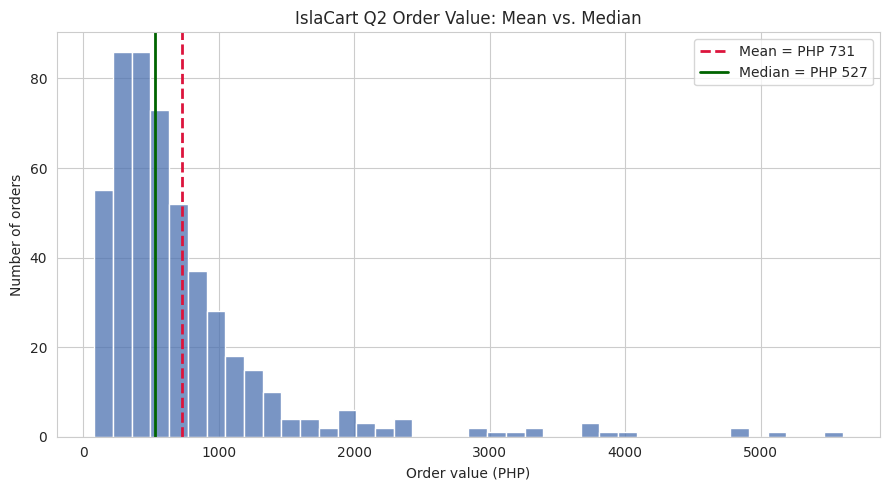

Skew (Fisher-Pearson): 3.34
Positive skew confirms: a small number of large orders (mostly VIP) are pulling the mean well above the median.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(orders_df["order_value_php"], bins=40, color="#4C72B0", ax=ax)
overall_mean = orders_df["order_value_php"].mean()
overall_median = orders_df["order_value_php"].median()

ax.axvline(overall_mean, color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = PHP {overall_mean:,.0f}")
ax.axvline(overall_median, color="darkgreen", linestyle="-", linewidth=2,
           label=f"Median = PHP {overall_median:,.0f}")
ax.set_title("IslaCart Q2 Order Value: Mean vs. Median")
ax.set_xlabel("Order value (PHP)")
ax.set_ylabel("Number of orders")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skew (Fisher-Pearson): {stats.skew(orders_df['order_value_php']):.2f}")
print("Positive skew confirms: a small number of large orders (mostly VIP) are",
      "pulling the mean well above the median.")

In [ ]:
# Mode is most meaningful for the ordinal / categorical columns, not currency
print("Modal shipping tier:", orders_df["shipping_tier"].mode()[0])
print("Modal satisfaction rating:", orders_df["customer_satisfaction"].mode()[0])
print("\nFull satisfaction distribution:")
print(orders_df["customer_satisfaction"].value_counts().sort_index())

Modal shipping tier: Standard
Modal satisfaction rating: 4

Full satisfaction distribution:
customer_satisfaction
1     14
2     28
3     76
4    202
5    180
Name: count, dtype: int64


### Business Application

Ana reports the **median order value per segment**, not the mean, when finance asks for "typical order size" -- the mean is reserved for **total revenue forecasting**, where every peso counts and skew is actually the point. She also flags the modal satisfaction rating (4 stars) alongside the distribution shape, so leadership sees that a meaningful minority of customers are unhappy (1-2 stars) rather than being reassured by a single blended average. The concrete recommendation to finance: forecast Q3 revenue using the **mean** (it should reflect total peso volume including VIP orders), but forecast **typical basket size for marketing promotions** using the **median**, since a promo designed around ₱2,072 would target almost nobody.

## Subtopic 3: Measures of Spread

### Intuition & Analogy

**Business Hook:** IslaCart's operations team wants to advertise a delivery-time promise on the checkout page. Ana's question: *"3 days" might be the average, but how much do delivery times actually vary — and does promising "3 days" set customers up for disappointment half the time?*

Picture two Manila-to-Cebu ferry routes that both advertise "average crossing time: 4 hours." Route A's crossings run 3.5 to 4.5 hours, rain or shine. Route B's crossings run anywhere from 2 to 9 hours depending on weather. Both have the same *average*, but only Route A's average is something you can actually plan a connecting trip around. Spread measures capture exactly this difference in reliability that a single "typical value" hides.

### Theory — By Hand

Take a 5-order extract of `delivery_days`: **2, 3, 2, 7, 3** (all Expedited-tier orders; one delayed shipment).

**Range:**
$$\text{range} = \max(x) - \min(x) = 7 - 2 = 5 \text{ days}$$

**Variance** (population form, since this extract is treated as the full population of interest for the by-hand check):
$$\bar{x} = \frac{2+3+2+7+3}{5} = \frac{17}{5} = 3.4$$
$$\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2 = \frac{(2-3.4)^2+(3-3.4)^2+(2-3.4)^2+(7-3.4)^2+(3-3.4)^2}{5}$$
$$= \frac{1.96 + 0.16 + 1.96 + 12.96 + 0.16}{5} = \frac{17.2}{5} = 3.44$$

**Standard deviation:**
$$\sigma = \sqrt{\sigma^2} = \sqrt{3.44} \approx 1.855 \text{ days}$$

**Interquartile range (IQR):** sort the values: 2, 2, 3, 3, 7. Using the median-of-halves method, the lower half (excluding the overall median) is {2, 2}, so $Q_1 = 2$; the upper half is {3, 7}, so $Q_3 = 5$.
$$\text{IQR} = Q_3 - Q_1 = 5 - 2 = 3 \text{ days}$$

Compare range (5) to IQR (3): the range is inflated by the single 7-day delay, while the IQR — built from the middle 50% of the data — barely notices it. This is the same lesson as Subtopic 2 applied to spread: **range and standard deviation are sensitive to outliers; IQR is not.**

In [ ]:
extract = np.array([2, 3, 2, 7, 3])

rng_val = extract.max() - extract.min()
var_pop = extract.var(ddof=0)     # population variance, matches by-hand
std_pop = extract.std(ddof=0)
q1, q3 = np.percentile(extract, [25, 75])
iqr_val = q3 - q1

print(f"Range:              {rng_val}")
print(f"Variance (pop.):    {var_pop:.4f}")
print(f"Std dev (pop.):     {std_pop:.4f}")
print(f"Q1={q1}, Q3={q3}, IQR={iqr_val}")

Range:              5
Variance (pop.):    3.4400
Std dev (pop.):     1.8547
Q1=2.0, Q3=3.0, IQR=1.0


### By Tool

At full scale, we compare delivery-time spread across shipping tiers and regions -- exactly the breakdown Ana needs before operations commits to a checkout-page promise.

In [ ]:
spread_by_tier = orders_df.groupby("shipping_tier", observed=True)["delivery_days"].agg(
    mean="mean",
    range=lambda s: s.max() - s.min(),
    variance=lambda s: s.var(ddof=1),
    std="std",
    iqr=lambda s: np.percentile(s, 75) - np.percentile(s, 25),
).round(2)
spread_by_tier

,mean,range,variance,std,iqr
shipping_tier,,,,,
Standard,3.93,6.3,0.95,0.97,1.3
Expedited,2.17,4.8,0.97,0.98,1.3
Overnight,0.85,2.8,0.54,0.74,1.2


/tmp/ipykernel_505/3671320534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


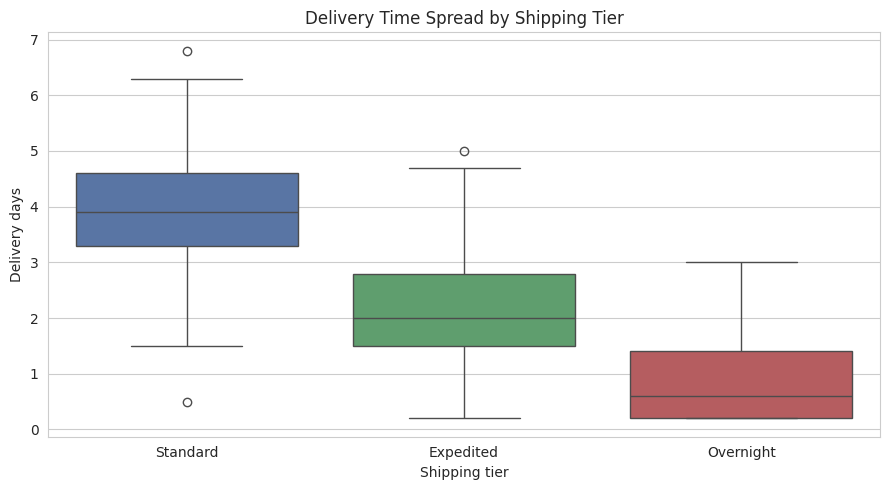

Coefficient of variation (std / mean) by tier -- lets us compare relative spread across tiers with very different average delivery times:
shipping_tier
Standard     0.248
Expedited    0.453
Overnight    0.868
Name: delivery_days, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=orders_df, x="shipping_tier", y="delivery_days",
    order=["Standard", "Expedited", "Overnight"],
    palette=["#4C72B0", "#55A868", "#C44E52"], ax=ax
)
ax.set_title("Delivery Time Spread by Shipping Tier")
ax.set_xlabel("Shipping tier")
ax.set_ylabel("Delivery days")
plt.tight_layout()
plt.show()

print("Coefficient of variation (std / mean) by tier -- lets us compare",
      "relative spread across tiers with very different average delivery times:")
cv = orders_df.groupby("shipping_tier", observed=True)["delivery_days"].agg(
    lambda s: s.std() / s.mean()
).round(3)
print(cv)

### Business Application

Ana recommends operations advertise delivery windows using **median ± IQR**, not "average delivery time," because outlier delays (weather, warehouse backlogs) inflate the mean and standard deviation without reflecting what most customers experience. Concretely: Standard shipping should be marketed as "3-5 business days" (built from the IQR) rather than "4 days on average," which would be broken by any single bad week. Overnight shipping's low standard deviation is itself a selling point Ana flags to marketing — it's not just faster, it's more *predictable*, and predictability is what justifies the price premium.

## Subtopic 4: Putting It Together — Profiling a Raw Dataset Before Trusting Any Number

### Intuition & Analogy

**Business Hook:** before finance builds a single forecast on this export, Ana runs one question past herself: *if I reported any number from this raw file right now, would I be embarrassed to defend it in the leadership meeting?*

A dataset profiling pass is the same discipline as a pilot's pre-flight checklist. No single item on the checklist is complicated -- fuel level, flap position, instrument calibration -- but skipping the checklist because "the plane looked fine yesterday" is exactly how small, individually survivable problems compound into a real failure. A raw data export deserves the same five-minute discipline before a single mean or median from it reaches a slide deck.

### Theory — By Hand

Take four freshly-exported rows, deliberately including the kinds of defects Ana finds weekly:

| `order_id` | `customer_satisfaction` | `order_value_php` | `region` | `delivery_days` |
|---|---|---|---|---|
| IC-00201 | 4 | 610.00 | Cebu City | 3.1 |
| IC-00201 | 4 | 610.00 | Cebu City | 3.1 |
| IC-00219 | 7 | 340.00 | Mandaue | 2.0 |
| IC-00233 | 3 | -85.00 | *(missing)* | 1.8 |

A profiling pass, run by hand on these four rows:

1. **Duplicates:** `IC-00201` appears twice with identical values across every column -- almost certainly a duplicate export row, not two genuine orders. Counting it twice would double-count that customer's revenue and inflate order volume.
2. **Impossible / out-of-range values:** `customer_satisfaction = 7` for `IC-00219` violates the known scale (1-5 stars). This is either a data-entry error or a different scale that got merged in by mistake -- either way, it cannot be trusted as-is.
3. **Logically invalid values:** `order_value_php = -85.00` for `IC-00233` is a ratio variable with a true zero; a negative order value is not meaningful (unless it specifically represents a refund, which would need its own flag/column, not a silent negative in the same field as sales).
4. **Missing values:** `region` is blank for `IC-00233`. Before dropping or imputing, Ana asks *why* it's missing -- a checkout bug, a manual order, or a genuinely unrecorded region each imply a different fix.

None of these four issues would show up in `df.describe()` alone -- variance and the mean would compute without error and *look* like real numbers, which is precisely what makes unprofiled data dangerous.

In [ ]:
# Reconstructing the by-hand example to verify each defect programmatically
sample_rows = pd.DataFrame({
    "order_id": ["IC-00201", "IC-00201", "IC-00219", "IC-00233"],
    "customer_satisfaction": [4, 4, 7, 3],
    "order_value_php": [610.00, 610.00, 340.00, -85.00],
    "region": ["Cebu City", "Cebu City", "Mandaue", None],
    "delivery_days": [3.1, 3.1, 2.0, 1.8],
})

print("Duplicate rows:\n", sample_rows[sample_rows.duplicated(keep=False)], "\n")
print("Out-of-range satisfaction (expected 1-5):\n",
      sample_rows[~sample_rows["customer_satisfaction"].between(1, 5)], "\n")
print("Negative order values:\n",
      sample_rows[sample_rows["order_value_php"] < 0], "\n")
print("Missing values per column:\n", sample_rows.isnull().sum())

Duplicate rows:
    order_id  customer_satisfaction  order_value_php     region  delivery_days
0  IC-00201                      4            610.0  Cebu City            3.1
1  IC-00201                      4            610.0  Cebu City            3.1 

Out-of-range satisfaction (expected 1-5):
    order_id  customer_satisfaction  order_value_php   region  delivery_days
2  IC-00219                      7            340.0  Mandaue            2.0 

Negative order values:
    order_id  customer_satisfaction  order_value_php region  delivery_days
3  IC-00233                      3            -85.0    NaN            1.8 

Missing values per column:
 order_id                 0
customer_satisfaction    0
order_value_php          0
region                   1
delivery_days            0
dtype: int64


### By Tool

To make the full-scale example realistic, we inject the same categories of defects into a copy of the 500-row export, then run the profiling pass Ana actually uses on every new IslaCart file.

In [ ]:
# Inject realistic data-quality issues into a COPY of the clean export,
# to demonstrate the profiling workflow on defects that mirror Subtopic 4's
# by-hand example (duplicates, out-of-range values, invalid negatives, missing data).
messy_df = orders_df.copy()

dup_rows = messy_df.sample(6, random_state=1)
messy_df = pd.concat([messy_df, dup_rows], ignore_index=True)

bad_rating_idx = messy_df.sample(4, random_state=2).index
messy_df.loc[bad_rating_idx, "customer_satisfaction"] = 7

bad_value_idx = messy_df.sample(3, random_state=3).index
messy_df.loc[bad_value_idx, "order_value_php"] = -abs(
    messy_df.loc[bad_value_idx, "order_value_php"]
)

missing_region_idx = messy_df.sample(15, random_state=4).index
messy_df.loc[missing_region_idx, "region"] = None

missing_satisfaction_idx = messy_df.sample(9, random_state=5).index
messy_df.loc[missing_satisfaction_idx, "customer_satisfaction"] = np.nan

print(f"Messy export shape: {messy_df.shape}")

Messy export shape: (506, 9)


In [ ]:
def profile_dataset(df):
    report = {}
    report["n_rows"] = len(df)
    report["n_duplicate_rows"] = int(df.duplicated().sum())
    report["missing_by_column"] = df.isnull().sum()
    report["missing_by_column"] = report["missing_by_column"][
        report["missing_by_column"] > 0
    ]

    out_of_range = {}
    if "customer_satisfaction" in df.columns:
        mask = ~df["customer_satisfaction"].between(1, 5) & df["customer_satisfaction"].notna()
        out_of_range["customer_satisfaction (expected 1-5)"] = int(mask.sum())
    if "order_value_php" in df.columns:
        mask = df["order_value_php"] < 0
        out_of_range["order_value_php (negative)"] = int(mask.sum())
    report["out_of_range_counts"] = out_of_range

    if "order_value_php" in df.columns:
        q1, q3 = df["order_value_php"].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        report["order_value_outlier_count"] = int(
            ((df["order_value_php"] < lower) | (df["order_value_php"] > upper)).sum()
        )
    return report

profile = profile_dataset(messy_df)
print(f"Rows: {profile['n_rows']}")
print(f"Exact duplicate rows: {profile['n_duplicate_rows']}")
print(f"\nMissing values by column:\n{profile['missing_by_column']}")
print(f"\nOut-of-range value counts:\n{profile['out_of_range_counts']}")
print(f"\nOrder value outliers (1.5x IQR rule): {profile['order_value_outlier_count']}")

Rows: 506
Exact duplicate rows: 5

Missing values by column:
region                   15
customer_satisfaction     9
dtype: int64

Out-of-range value counts:
{'customer_satisfaction (expected 1-5)': 4, 'order_value_php (negative)': 3}

Order value outliers (1.5x IQR rule): 39


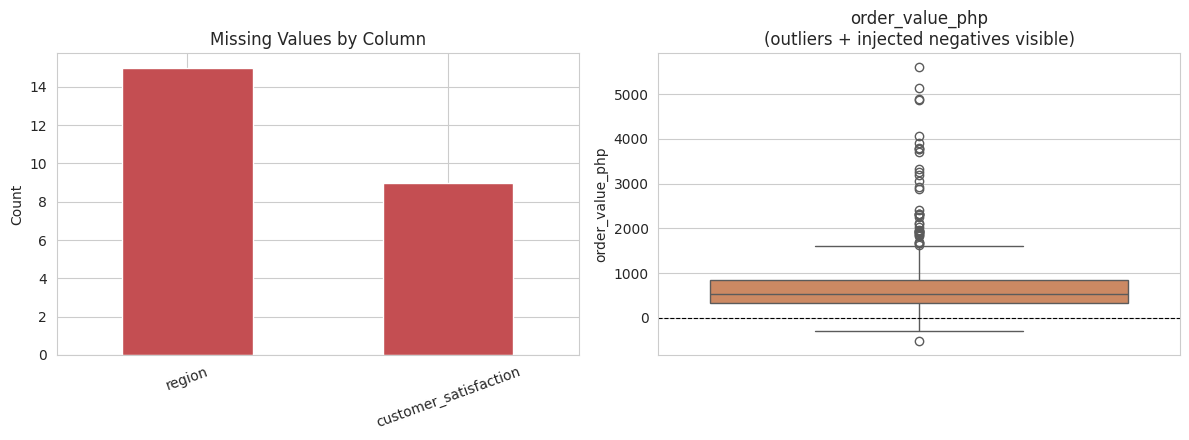

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

missing_counts = messy_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_counts.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Missing Values by Column")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(y=messy_df["order_value_php"], ax=axes[1], color="#DD8452")
axes[1].set_title("order_value_php\n(outliers + injected negatives visible)")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

### Business Application

Ana's standard pre-forecast checklist -- duplicate check, missing-value map, range/validity check per column, outlier flag on every ratio variable -- runs in under a minute against a dataset this size and catches every defect before it reaches finance's Q3 model. Her concrete recommendation to the data engineering team: block the raw export from the shared drive until `n_duplicate_rows == 0` and all `customer_satisfaction` values fall within 1-5, since those two checks alone would have caught the defects seen here. Everything computed in Subtopics 1-3 -- the mean, median, variance, and IQR -- is only trustworthy once this profiling pass has been run; profiling isn't a separate step from descriptive statistics, it's the step that makes descriptive statistics safe to report at all.

## Key Takeaways

**Data types and levels of measurement**
- Nominal: labels only, no order (`region`, `product_category`) -- never average.
- Ordinal: ordered, gaps not guaranteed equal (`shipping_tier`, `customer_satisfaction`) -- median over mean.
- Interval: ordered, equal gaps, no true zero (`order_date`) -- differences valid, ratios are not.
- Ratio: ordered, equal gaps, true zero (`order_value_php`, `delivery_days`) -- full arithmetic is valid.

**Central tendency**
- Mean is pulled toward outliers/skew; median is robust to them.
- Mode is most useful for categorical/discrete data, not continuous currency values.
- A large mean-to-median ratio is itself a diagnostic for skew -- check it before reporting either number alone.
- Multimodal distributions hide behind a single mean; check the histogram, not just the summary number.

**Spread**
- Range and standard deviation are sensitive to outliers; IQR is not.
- Coefficient of variation (std / mean) lets you compare spread across groups with different scales or averages.
- "Typical value ± spread" (e.g., median ± IQR) is more decision-useful than either number alone.

**Profiling before trusting a number**
- Check, in order: duplicates, missing values, out-of-range/invalid values, outliers.
- `df.describe()` will run without error on badly broken data -- absence of an error is not evidence of data quality.
- Profiling is not a preliminary step separate from descriptive statistics; it's the precondition for any of those statistics being trustworthy.

## References

Freedman, D., Pisani, R., & Purves, R. (2007). *Statistics* (4th ed.). W. W. Norton & Company.

Stevens, S. S. (1946). On the theory of scales of measurement. *Science*, 103(2684), 677-680. https://doi.org/10.1126/science.103.2684.677

Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10), 1-23. https://doi.org/10.18637/jss.v059.i10

McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.